In [2]:
#Importing all important Libraries
import pandas as pd
import numpy as np
from scipy.optimize import minimize_scalar, least_squares
import matplotlib.pyplot as plt

In [3]:
#Accessing the dataset 
df = pd.read_csv('Dataset.csv')
x_data = df['x'].values
y_data = df['y'].values
n = len(df)
print(f"Loaded {n} points")
df.head()

Loaded 1500 points


,x,y
0,88.364456,57.784378
1,74.283936,54.406780
2,60.256474,46.311462
3,82.134370,57.717567
4,101.036390,67.849340


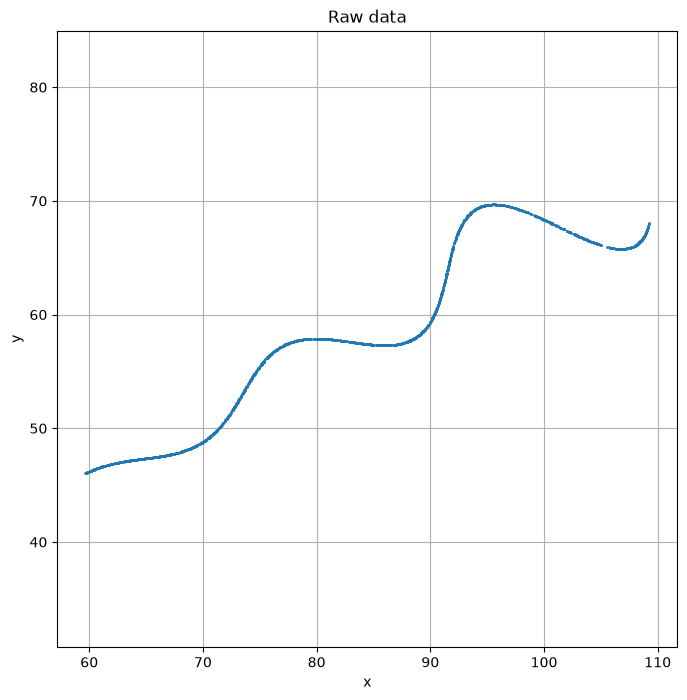

The curve seems like a oscillating curve based on the value of t


In [4]:
#Plotting the raw points of the dataset to check how the data is represented 
plt.figure(figsize=(8,8))
plt.plot(x_data, y_data, '.', markersize=2)
plt.xlabel('x'); plt.ylabel('y')
plt.title('Raw data')
plt.axis('equal'); plt.grid(True)
plt.show()
print('The curve seems like a oscillating curve based on the value of t')

In [ ]:
def error_vector(params):
    """
    Given a guess (theta, M, X), undo the rotation/shift on every data point.
    If theta and X are correct, t_calc becomes the exact original t for that point,
    and S_calc becomes the exact height of the sine envelope at that t.
    The error is how far S_calc is from what the envelope formula predicts (S_expected).
    """
    theta, M, X = params
    
 
    x0 = x_data - X
    y0 = y_data - 42
    

    t_calc = x0 * np.cos(theta) + y0 * np.sin(theta)
    S_calc = -x0 * np.sin(theta) + y0 * np.cos(theta)
    

    S_expected = np.exp(M * np.abs(t_calc)) * np.sin(0.3 * t_calc)
    
    return S_calc - S_expected
    print('Inital Calculation')

In [17]:
def pca_theta_estimate(x_data, y_data):
    """
    Estimate theta from the data's principal axis of variance 
    """
    mean_x, mean_y = x_data.mean(), y_data.mean()
    xc = x_data - mean_x
    yc = y_data - mean_y
    
    cov = np.cov(xc, yc)
    eigvals, eigvecs = np.linalg.eigh(cov)
    principal = eigvecs[:, np.argmax(eigvals)]  # eigenvector with largest eigenvalue
    
    angle_deg = np.rad2deg(np.arctan2(principal[1], principal[0])) % 180
    if angle_deg > 90:
        angle_deg = 180 - angle_deg
    
    return np.deg2rad(angle_deg), mean_x, mean_y

theta_pca, mean_x, mean_y = pca_theta_estimate(x_data, y_data)
print(f"PCA-based initial theta estimate: {np.rad2deg(theta_pca):.4f} degrees")

# also get a rough initial X using the PCA theta and t's known midpoint (33)
X_initial = mean_x - 33 * np.cos(theta_pca)
print(f"Initial X estimate: {X_initial:.4f}")
print('Initial value of X and theta to start with optimizer')

PCA-based initial theta estimate: 28.4831 degrees
Initial X estimate: 54.7083
Initial value of X and theta to start with optimizer


In [18]:
initial_guess = [theta_pca, 0.0, X_initial]

result = least_squares(
    error_vector,
    x0=initial_guess,
    bounds=([0, -0.05, 0], [np.deg2rad(50), 0.05, 100])
)

theta, M, X = result.x
print(f"theta = {np.rad2deg(theta):.6f} degrees ({theta:.10f} rad)")
print(f"M     = {M:.8f}")
print(f"X     = {X:.6f}")
print(f"Total residual cost: {np.sum(np.abs(result.fun)):.6f}")

theta = 29.999973 degrees (0.5235983032 rad)
M     = 0.03000000
X     = 54.999998
Total residual cost: 0.003840
